## 📝 KNN Clasifier Project
---

Bu projede, çeşitli kimyasal özelliklerine (Kırılma indeksi, Sodyum, Magnezyum vb.) dayanarak cam türlerini sınıflandıran bir **Makine Öğrenimi modeli** geliştirilmiştir. Veri seti, sınıflar arası dengesizlik (class imbalance) ve yüksek aykırı değer (outlier) oranlarına sahip olduğundan, veri ön işleme ve model doğrulama aşamalarında özel teknikler (Robust Scaling ve Stratified K-Fold) kullanılmıştır.

**Amaç:** K-Nearest Neighbors (KNN) algoritmasını kullanarak, kimyasal bileşenlerine göre camın kullanım alanını (bina camı, araç camı vb.) en yüksek doğrulukla tahmin etmek.

#### --- 1. KÜTÜPHANELER ---

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold


# Profesyonel grafik ayarları (Grafiklerin daha net ve okunabilir olması için)
sns.set_style("ticks") 
plt.rcParams['figure.dpi'] = 100
import warnings
warnings.filterwarnings("ignore") # Okunabilirliği artırmak için uyarıları gizliyoruz

## 📝 Veri Yükleme ve Özellik Sözlüğü

### 1. Veri Yükleme ve Keşifsel Veri Analizi (EDA)
Veri setimizi yükleyerek temel özelliklerini inceliyoruz. Hedef değişkenimiz olan Type, camın kullanım alanını temsil eden 6 farklı sınıftan oluşmaktadır.

**Veri Sözlüğü (Data Dictionary):**

* RI: Kırılma indeksi (Refractive Index)
* Na: Sodyum (Ağırlık yüzdesi)
* Mg: Magnezyum
* Al: Alüminyum
* Si: Silisyum
* K: Potasyum
* Ca: Kalsiyum
* Ba: Baryum
* Fe: Demir
    
**Hedef Değişken (Type):**

1- Bina pencereleri (float işlem görmüş)

2- Bina pencereleri (float işlem görmemiş)

3- Araç pencereleri (float işlem görmüş)

4 -Kaplar/Konteynerlar

5- Sofra takımı

6- Farlar

In [2]:
df = pd.read_csv("glass.csv")

In [3]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [4]:
df['Type'].unique()

array([1, 2, 3, 5, 6, 7], dtype=int64)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [6]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


## 📝 Korelasyon ve Dağılım Analizi
----

#### 1.1 Özellikler Arası Korelasyon
Değişkenlerin birbirleriyle ve hedef değişkenle olan doğrusal ilişkilerini anlamak için bir korelasyon matrisi oluşturuyoruz. Matrisin simetrik yapısından dolayı tekrar eden bilgileri gizlemek adına üst üçgen (upper triangle) maskelemesi kullanılmıştır.

In [7]:
df.corr()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
RI,1.000000,-0.191885,-0.122274,-0.407326,-0.542052,-0.289833,0.810403,-0.000386,0.143010,-0.164237
Na,-0.191885,1.000000,-0.273732,0.156794,-0.069809,-0.266087,-0.275442,0.326603,-0.241346,0.502898
Mg,-0.122274,-0.273732,1.000000,-0.481799,-0.165927,0.005396,-0.443750,-0.492262,0.083060,-0.744993
Al,-0.407326,0.156794,-0.481799,1.000000,-0.005524,0.325958,-0.259592,0.479404,-0.074402,0.598829
Si,-0.542052,-0.069809,-0.165927,-0.005524,1.000000,-0.193331,-0.208732,-0.102151,-0.094201,0.151565
K,-0.289833,-0.266087,0.005396,0.325958,-0.193331,1.000000,-0.317836,-0.042618,-0.007719,-0.010054
Ca,0.810403,-0.275442,-0.443750,-0.259592,-0.208732,-0.317836,1.000000,-0.112841,0.124968,0.000952
Ba,-0.000386,0.326603,-0.492262,0.479404,-0.102151,-0.042618,-0.112841,1.000000,-0.058692,0.575161
Fe,0.143010,-0.241346,0.083060,-0.074402,-0.094201,-0.007719,0.124968,-0.058692,1.000000,-0.188278
Type,-0.164237,0.502898,-0.744993,0.598829,0.151565,-0.010054,0.000952,0.575161,-0.188278,1.000000


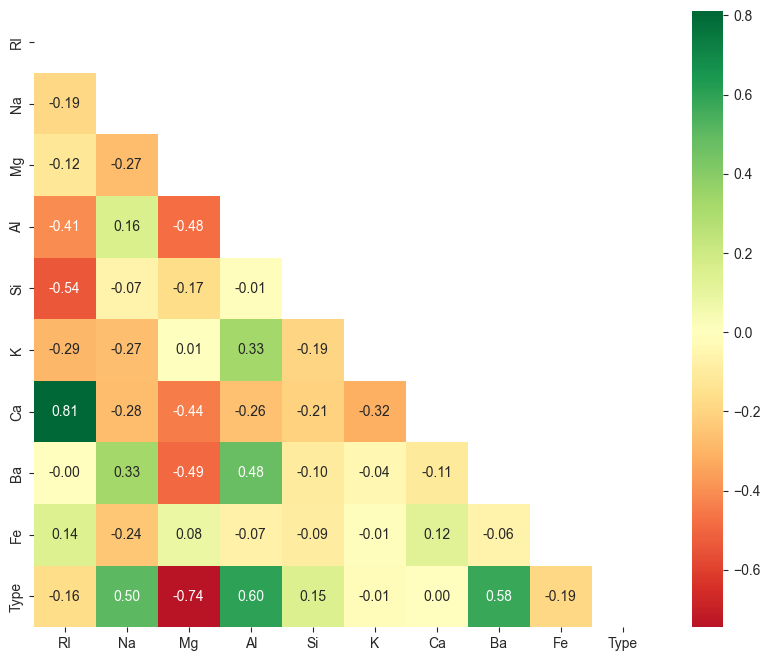

In [8]:
# 1. Korelasyon matrisini hesapla
corr = df.corr()

# 2. Üst üçgeni kapatacak bir maske oluştur
# np.triu (triangle upper) üst üçgeni seçer, biz bunu maske olarak kullanacağız
mask = np.triu(np.ones_like(corr, dtype=bool))

# 3. Heatmap'i çizdir
plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, cmap='RdYlGn', fmt=".2f", center=0)

plt.show()

## 📝 Sınıf Dağılımı
---

#### 1.2 Sınıf Dengesizliği (Class Imbalance) Analizi
Aşağıdaki grafikte görüleceği üzere, Tip 1 ve Tip 2 (Bina camları) veri setini domine ederken; Tip 3, 5 ve 6 çok daha az örneğe sahiptir. Bu dengesizlik, model eğitiminde azınlık sınıflarının görmezden gelinmesine yol açabilir. Bu durumu ileriki aşamalarda **Stratified K-Fold** kullanarak ele alacağız.

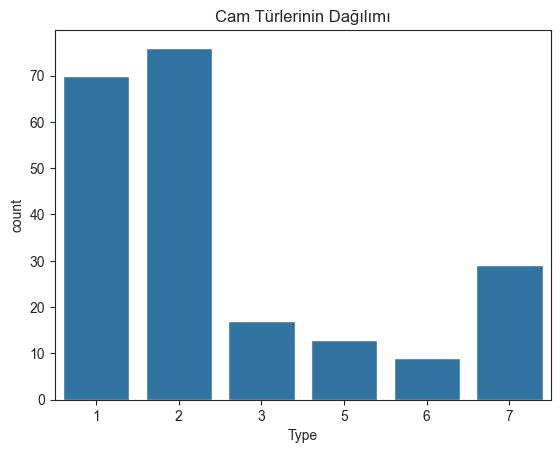

In [9]:
#Tip 1 ve Tip 2 (Bina camları) veri setini domine ederken, Tip 3, 5, 6 ve 7 çok daha az örneğe sahip.

sns.countplot(x='Type', data=df)
plt.title('Cam Türlerinin Dağılımı')
plt.show()

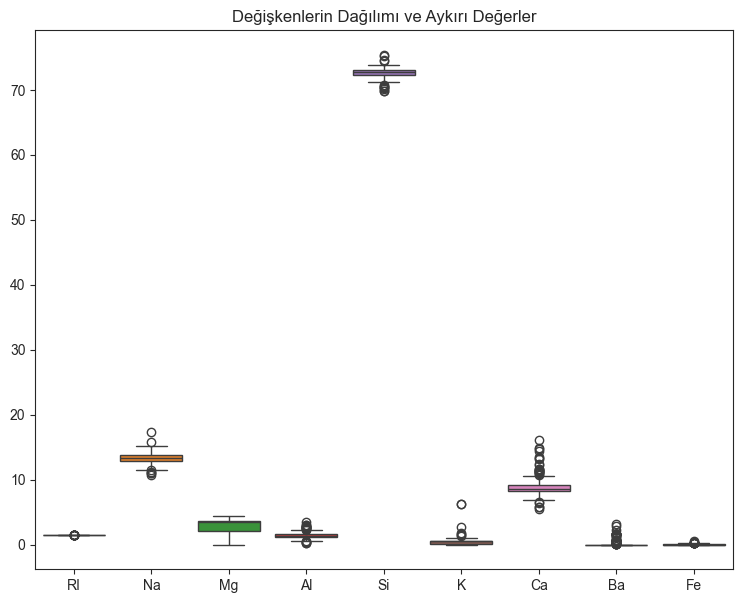

In [10]:
plt.figure(figsize=(9, 7))
sns.boxplot(data=df.drop('Type', axis=1))
plt.title('Değişkenlerin Dağılımı ve Aykırı Değerler')
plt.show()

## 📝 Aykırı Değer (Outlier) Analizi
---
#### 1.3 Aykırı Değer Analizi (Boxplots)
Makine öğrenimi modelleri (özellikle mesafe tabanlı olan **KNN** gibi algoritmalar) aykırı değerlere karşı son derece hassastır. Aşağıdaki kutu grafikleri (boxplot), kimyasal bileşenlerdeki aykırı değerlerin yoğunluğunu göstermektedir.

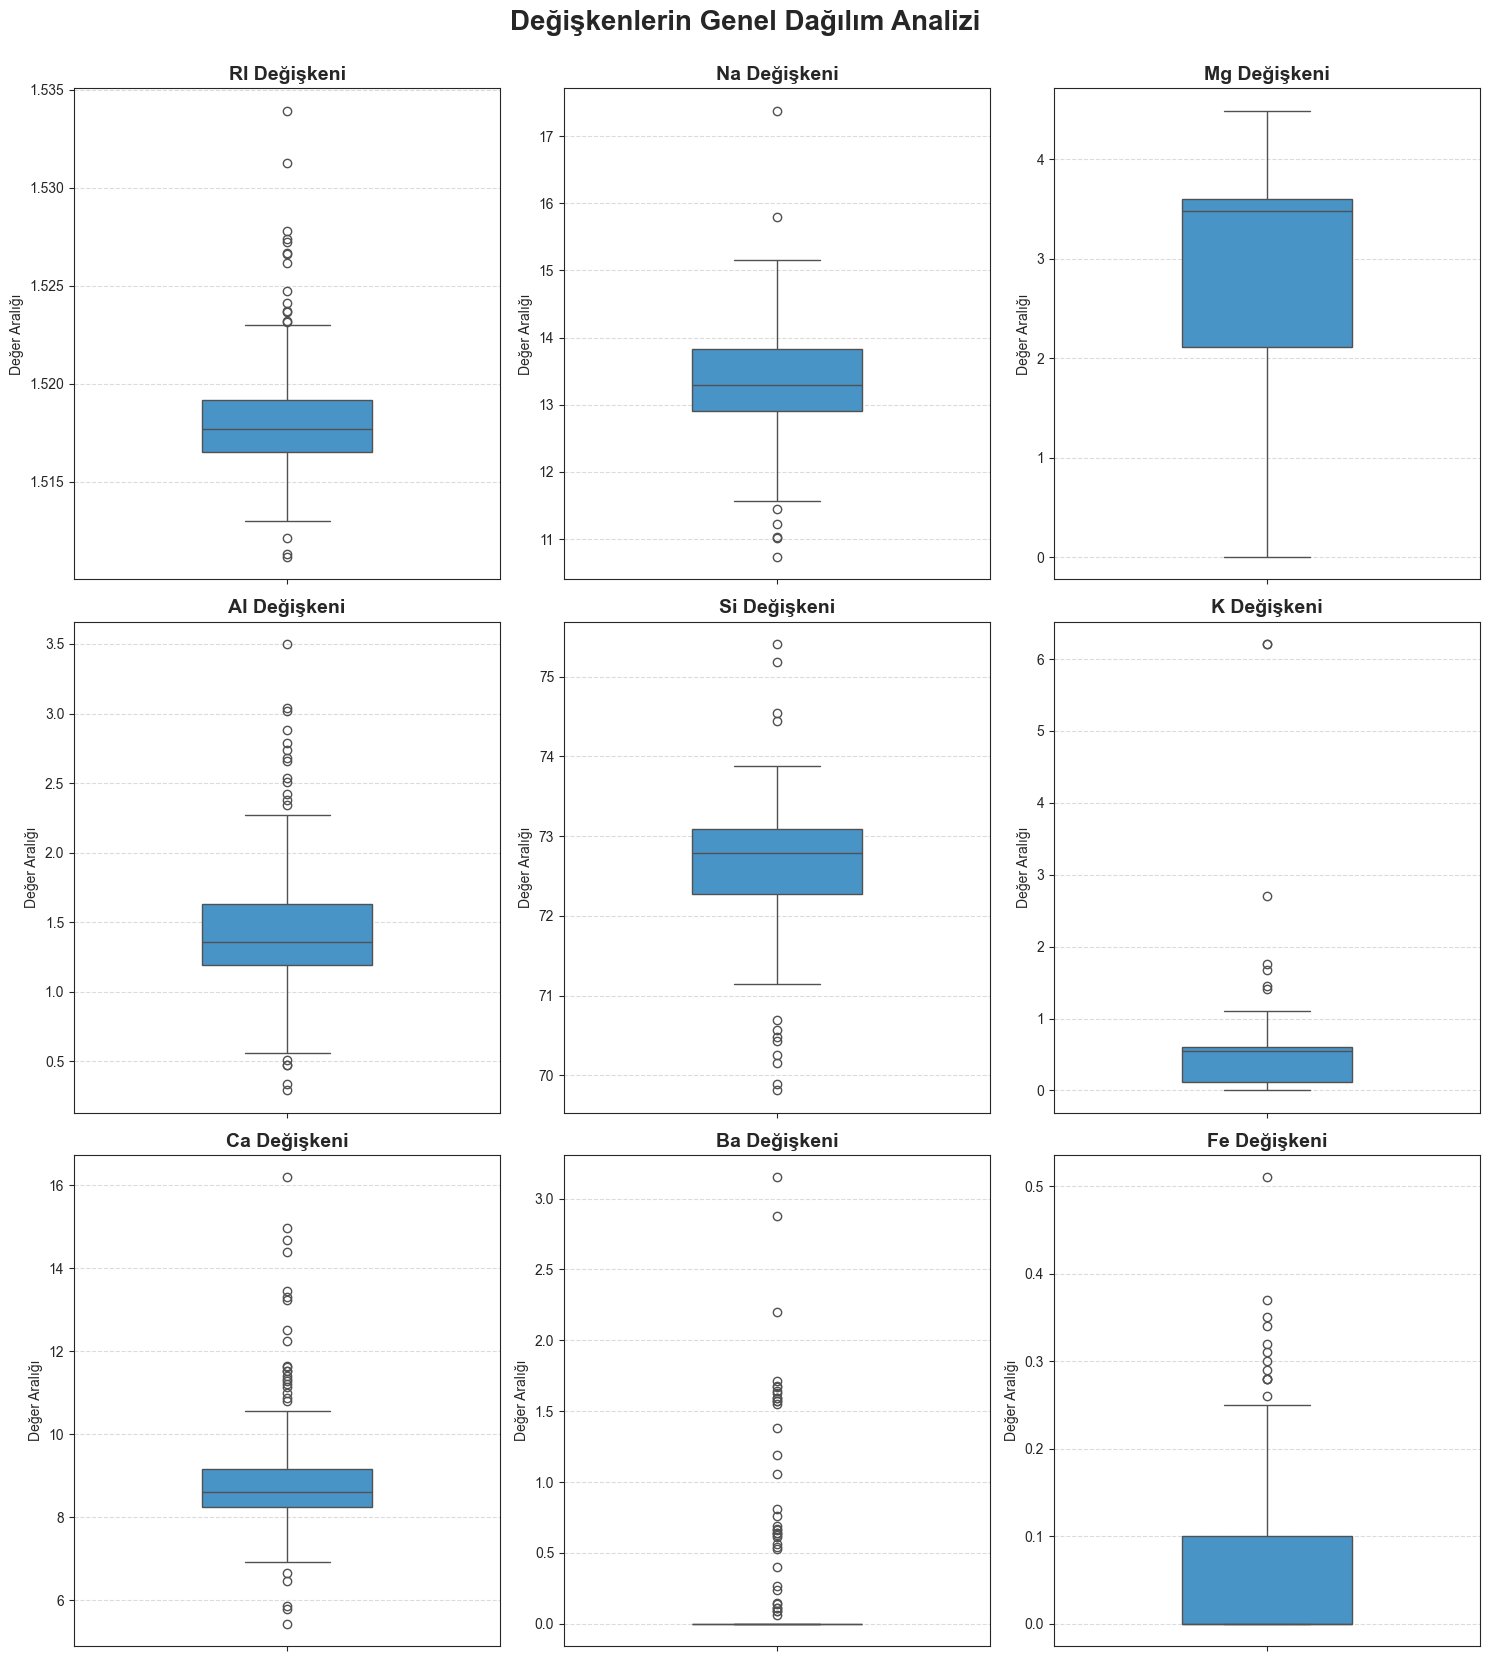

In [11]:
# Özellik listesi (Hedef değişken olan 'Type' hariç)
features = [col for col in df.columns if col != 'Type']

# 4 Satır, 3 Sütun düzeni
fig, axes = plt.subplots(3, 3, figsize=(15, 18))
fig.suptitle('Değişkenlerin Genel Dağılım Analizi', fontsize=20, fontweight='bold', y=0.95)

axes = axes.flatten()

for i, col in enumerate(features):
    # Boxplot çizimi
    sns.boxplot(y=df[col], ax=axes[i], color='#3498db', width=0.4)
    
    # Swarmplot ekleyerek veri noktalarının yoğunluğunu da görebilirsin (Opsiyonel)
    # sns.swarmplot(y=df[col], ax=axes[i], color='#2c3e50', size=2, alpha=0.5)
    
    axes[i].set_title(f'{col} Değişkeni', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Değer Aralığı')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

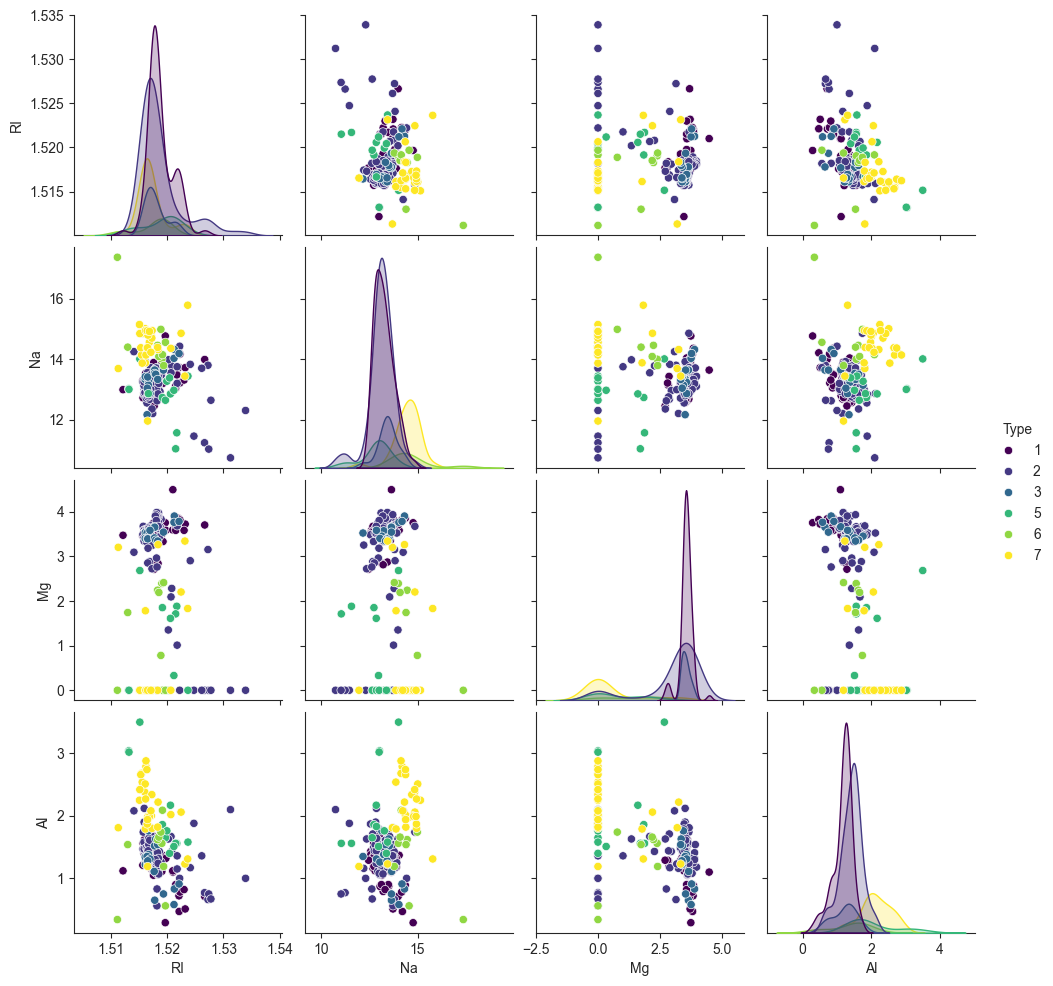

In [12]:
# Sadece birkaç önemli bileşeni seçerek daha net bir görüntü alabilirsin
sns.pairplot(df[['RI', 'Na', 'Mg', 'Al','Type']], hue='Type', palette='viridis')
plt.show()

In [13]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


## 📝 Veri Ön İşleme
---
### 2. Veri Hazırlığı ve Ölçeklendirme (Scaling)

Modelimizi eğitmeden önce veriyi Bağımsız (X) ve Bağımlı (y) değişkenler olarak ayırıyoruz. Ardından veri setini %80 Eğitim (Train) ve %20 Test olarak bölüyoruz.

💡 Mühendislik Notu: Neden RobustScaler?
Kutu grafiklerinde görüldüğü üzere veri setinde yüksek miktarda **aykırı değer (outlier)** bulunmaktadır. Standartlaştırma işleminde ortalama (mean) kullanan StandardScaler, bu aykırı değerlerden olumsuz etkilenir. **RobustScaler** ise ortalama yerine medyan ($Q_2$) ve varyans yerine Çeyrekler Açıklığı ($IQR = Q_3 - Q_1$) kullanarak aykırı değerlere karşı dirençli bir ölçeklendirme yapar.


In [14]:
X = df.drop("Type" , axis=1)
y = df["Type"]

In [15]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state=42)

In [16]:
scaler = RobustScaler()

In [17]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 📝 Hiperparametre Optimizasyonu
---
### 3. Hiperparametre Optimizasyonu (GridSearchCV)
KNN (K-En Yakın Komşu) algoritması, tahmin yaparken kendisine **en yakın 'k'** sayıdaki veri noktasının sınıfına bakar. **En iyi 'k'** değerini, mesafe ölçüm metriğini ve ağırlıklandırma yöntemini bulmak için GridSearchCV kullanarak sistematik bir arama yapacağız.

**Sınıf Dengesizliğine Karşı Stratified K-Fold:**
Normal K-Fold, veriyi rastgele böler. Ancak bizim veri setimizde "Araç pencereleri" (Tip 3) gibi çok az bulunan sınıflar var. Normal bölünmede bu sınıfların bazı fold'lara hiç düşmeme riski vardır. StratifiedKFold, veriyi bölerken orijinal veri setindeki sınıf oranlarını (örneğin %70 Tip 1, %5 Tip 3) her bir parçada (fold) birebir korur.

In [18]:
# Denenmesini istediğimiz parametre kombinasyonları sözlüğü
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 19],    # Oylama eşitliğini bozmamak için tek sayılar tercih edilir
    'weights': ['uniform', 'distance'],         # Uzaklığa göre ağırlıklandırma opsiyonları
    'metric': ['euclidean', 'manhattan'],       # Mesafe ölçüm metrikleri
}

In [19]:
# Modeli tanımla
model = KNeighborsClassifier()

'''
Veri setinde "Araç pencereleri" gibi çok az bulunan sınıflar olduğu için, Train/Test ayrımında her sınıfın oranını koruyan 
StratifiedKFold kullanmak hayat kurtarır.Sınıf dengesizliğine karşı Stratified K-Fold (Veriyi 5 parçaya böler)
'''
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# Grid Search'ü kur
grid_search = GridSearchCV(
    estimator=model, 
    param_grid=param_grid, 
    cv= cv_strategy,  # default'u 5
    scoring='accuracy', # Dengesiz verilerde burayı 'f1_weighted' olarak değiştirmek de çok etkilidir!
    n_jobs=-1 # İşlemi hızlandırmak için işlemcinin tüm çekirdeklerini kullan
)

In [20]:
grid_search.fit(X_train_scaled , y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and par

In [21]:
grid_search.best_params_

{'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}

## 📝 Final Model
---
### 4. Final Modelin Eğitilmesi ve Tahmin
**GridSearchCV** tarafından tespit edilen en ideal hiperparametre kombinasyonunu kullanarak nihai modelimizi kuruyoruz ve daha önce modelin hiç görmediği Test seti üzerinde tahminlerimizi gerçekleştiriyoruz.

In [22]:
# Grid Search'ün bulduğu en iyi parametrelerle final modelini kuruyorsun.
knn_model = KNeighborsClassifier(n_neighbors= 9 , metric= 'manhattan' , weights='distance')

In [23]:
knn_model.fit(X_train_scaled , y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",9
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'manhattan'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [24]:
y_pred = knn_model.predict(X_test_scaled)

## 📝 Model Değerlendirme
---
### 5. Model Değerlendirme ve Performans Analizi
Modelin performansını endüstri standartlarında değerlendirmek için **Karmaşıklık Matrisi (Confusion Matrix)** ve Sınıflandırma Raporunu (Classification Report) görselleştiriyoruz. Sadece **doğruluğa (Accuracy)** bakmak, sınıfların dengesiz olduğu veri setlerinde yanıltıcı olabilir. Bu nedenle sınıfların **Recall (Duyarlılık)** ve **Precision (Kesinlik)** metrikleri kritik önem taşır.

In [25]:
print("Accuracy Score:",accuracy_score(y_test,y_pred))

Accuracy Score: 0.7674418604651163


In [26]:
print("Confusion Matrix Score:",confusion_matrix(y_test,y_pred))

Confusion Matrix Score: [[11  0  0  0  0  0]
 [ 6  8  0  0  0  0]
 [ 2  1  0  0  0  0]
 [ 0  0  0  4  0  0]
 [ 0  0  0  0  2  1]
 [ 0  0  0  0  0  8]]


In [27]:
print("Classification Report Score:",classification_report(y_test,y_pred))

Classification Report Score:               precision    recall  f1-score   support

           1       0.58      1.00      0.73        11
           2       0.89      0.57      0.70        14
           3       0.00      0.00      0.00         3
           5       1.00      1.00      1.00         4
           6       1.00      0.67      0.80         3
           7       0.89      1.00      0.94         8

    accuracy                           0.77        43
   macro avg       0.73      0.71      0.70        43
weighted avg       0.77      0.77      0.74        43

